In [2]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client
from secrets import binance_api_key, binance_secret_key

In [3]:
client = Client(binance_api_key, binance_secret_key)
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

sample = get_sample("BTCUSDT")
sample.tail()

print(len(get_tickers()))

135


In [4]:
tickers = get_tickers()
ref = get_sample("ETHUSDT", start_date="1 Jan, 2020")
pre_samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Jan, 2020")
    if len(sample) < 220: continue
    
    # preprocess
    sample['noise'] = 1.-abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise15'] = sample['noise'].rolling(10).mean()
    sample['target_up'] = sample['open'] + sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['target_down'] = sample['open'] - sample['noise15']*(sample.shift(1)['high'] - sample.shift(1)['low'])
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['reward_up'] = 1. + sample['close'].pct_change()
    sample['reward_down'] = 1. - sample['close'].pct_change()
    sample['log_reward_up'] = np.log(sample['reward_up'])
    sample['log_reward_down'] = np.log(sample['reward_down'])
    sample['total_reward'] = sample['reward_up'].cumprod()
    sample.dropna(inplace=True)
    
    pre_samples[ticker] = sample.copy(); del sample
pre_samples['ETHUSDT'].tail(10)

,open,high,low,close,volume,noise,noise15,target_up,target_down,momentum,reward_up,reward_down,log_reward_up,log_reward_down,total_reward
datetime,,,,,,,,,,,,,,,
2021-12-02,4586.67,4636.86,4435.76,4514.32,1767131.692,0.640229,0.453940,4702.284089,4471.055911,0.104672,0.984228,1.015772,-0.015898,0.015649,34.560710
2021-12-03,4514.32,4658.00,4004.00,4213.66,2648380.120,0.540275,0.485827,4612.019844,4416.620156,-0.029415,0.933399,1.066601,-0.068923,0.064477,32.258919
2021-12-04,4213.67,4237.20,3388.15,4115.79,3531695.892,0.884718,0.508211,4546.040314,3881.299686,-0.036406,0.976773,1.023227,-0.023501,0.022961,31.509646
2021-12-05,4115.79,4247.19,4033.00,4197.53,1909767.851,0.618376,0.553365,4585.624199,3645.955801,-0.072955,1.019860,0.980140,0.019665,-0.020060,32.135431
2021-12-06,4197.52,4377.58,3920.00,4345.20,2601175.770,0.677259,0.596795,4325.347610,4069.692390,0.075369,1.035180,0.964820,0.034576,-0.035814,33.265962
2021-12-07,4345.44,4425.00,4255.27,4305.82,1388803.726,0.766570,0.608646,4623.944340,4066.935660,0.051398,0.990937,1.009063,-0.009104,0.009022,32.964477
2021-12-08,4305.83,4454.60,4224.98,4435.33,1443466.295,0.436025,0.611015,4409.537640,4202.122360,0.032288,1.030078,0.969922,0.029634,-0.030540,33.955979
2021-12-09,4435.70,4490.97,4075.00,4103.80,1905332.516,0.202106,0.613498,4576.571455,4294.828545,-0.076781,0.925252,1.074748,-0.077689,0.072086,31.417853
2021-12-10,4103.80,4232.00,3882.84,3895.95,2123045.506,0.404714,0.599449,4353.152799,3854.447201,-0.158816,0.949352,1.050648,-0.051976,0.049407,29.826596


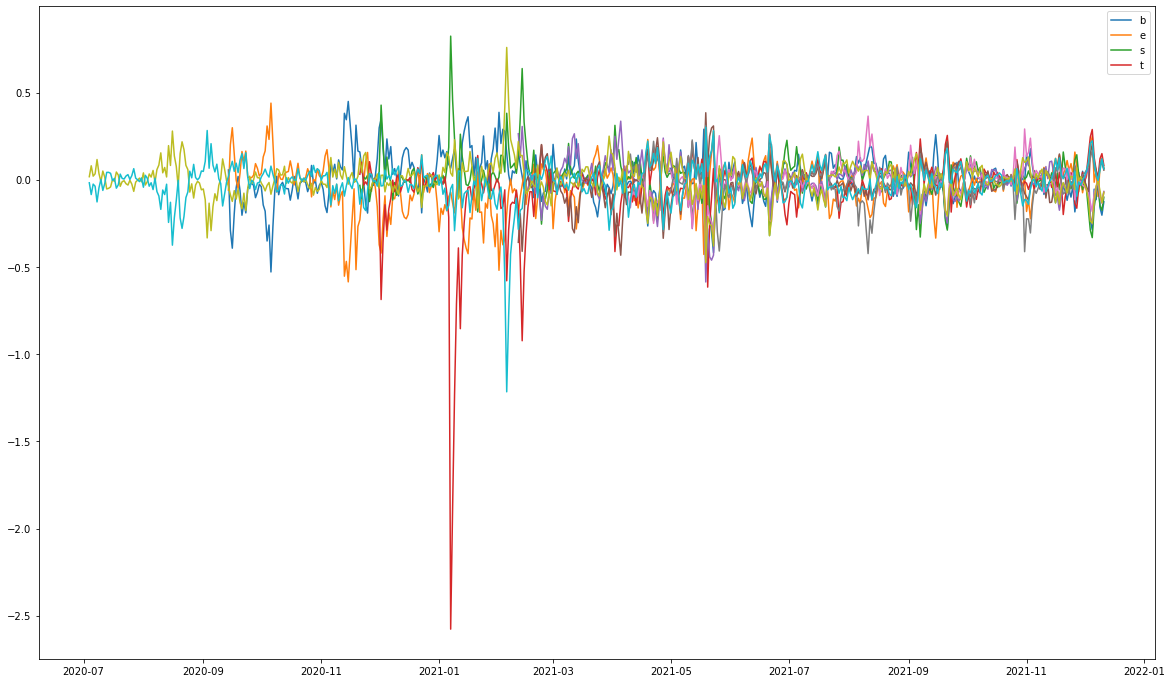

In [5]:
# make value functions
samples = dict()
for ticker in pre_samples.keys():
    sample = pre_samples[ticker].copy()
    sample['value_up'] = 0.
    sample['value_down'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up']
            sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down']
            continue
        
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value_up'] = sample.loc[idx, 'log_reward_up'] + gamma*(sample.shift(1).loc[idx, 'value_up'])
        sample.loc[idx, 'value_down'] = sample.loc[idx, 'log_reward_down'] + gamma*(sample.shift(1).loc[idx, 'value_down'])
    samples[ticker] = sample

plt.figure(figsize=(20, 12))
for ticker in list(samples.keys())[:5]:
    plt.plot(samples[ticker].index, samples[ticker].value_up, label=f"{ticker}-up")
    plt.plot(samples[ticker].index, samples[ticker].value_down, label=f"{ticker}-down")
plt.legend('best')
plt.show()

In [55]:
book = samples['BTCUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value_up'] = 0.
book['value_down'] = 0.

for idx in book.index:
    if idx in [ref.index[0], ref.index[-1]]: continue
    
    # select 21 highest volume coins
    volumes = dict()
    for ticker in samples.keys():
        try:
            volumes[ticker] = samples[ticker].loc[idx, 'close']*samples[ticker].loc[idx, 'volume']
        except:
            continue
    top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    # select 5 up, 5 down
    values = dict()
    for ticker in samples.keys():
        try:
            values[f"{ticker}-UP"] = samples[ticker].loc[idx, 'value_up']
            values[f"{ticker}-DOWN"] = samples[ticker].loc[idx, 'value_down']
        except:
            continue
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:6])
    
    book.loc[idx, 'value'] = np.mean(list(res.values()))
    
    reward = 0.
    leverage = 1.
    ratio = 1/len(res)
    
    for coin in res.keys():
        if "UP" in coin:
            ticker = coin[:-3]
            if samples[ticker].loc[idx, 'momentum'] < 0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] < 0.8:
                #reward += ratio
                reward += ratio*(1.+1.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./4.:
                    reward += 0.
                else:
                    reward += ratio*(1.+4.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
        else:
            ticker = coin[:-5]
            if samples[ticker].loc[idx, 'momentum'] > -0.3:
                reward += ratio
            elif samples[ticker].loc[idx, 'momentum'] > -0.6:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./2.:
                    reward += 0.
                else:
                    reward += ratio*(1.+2.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
            else:
                if samples[ticker].loc[idx, 'close']/samples[ticker].shift(-1).loc[idx, 'low'] - 1. < -1./12.:
                    reward += 0.
                else:
                    reward += ratio*(1.+12.*(samples[ticker].shift(-1).loc[idx, 'reward_up']-1.002))
    book.loc[idx, 'reward'] = reward
book.dropna(inplace=True)
book.tail(20)    

,close,number,reward,value_up,value_down,value
datetime,,,,,,
2021-11-21,58661.39,18952.0,1.031856,0.0,0.0,0.243932
2021-11-22,56268.31,18953.0,1.038761,0.0,0.0,0.187800
2021-11-23,57574.23,18954.0,1.277767,0.0,0.0,0.260874
2021-11-24,57165.08,18955.0,0.894418,0.0,0.0,0.361315
2021-11-25,58988.21,18956.0,0.899616,0.0,0.0,0.294058
2021-11-26,53755.65,18957.0,0.974225,0.0,0.0,0.249006
2021-11-27,54738.77,18958.0,0.973655,0.0,0.0,0.217431
2021-11-28,57315.73,18959.0,0.977593,0.0,0.0,0.151945
2021-11-29,57827.98,18960.0,0.946840,0.0,0.0,0.168670


==== value trading ====
Accumulated Returns: 2376651.71 %
CAGR: 19032.12 %
MDD: -70.45 %
VOL: 373.507 %
Sharpe: 10024.77 %


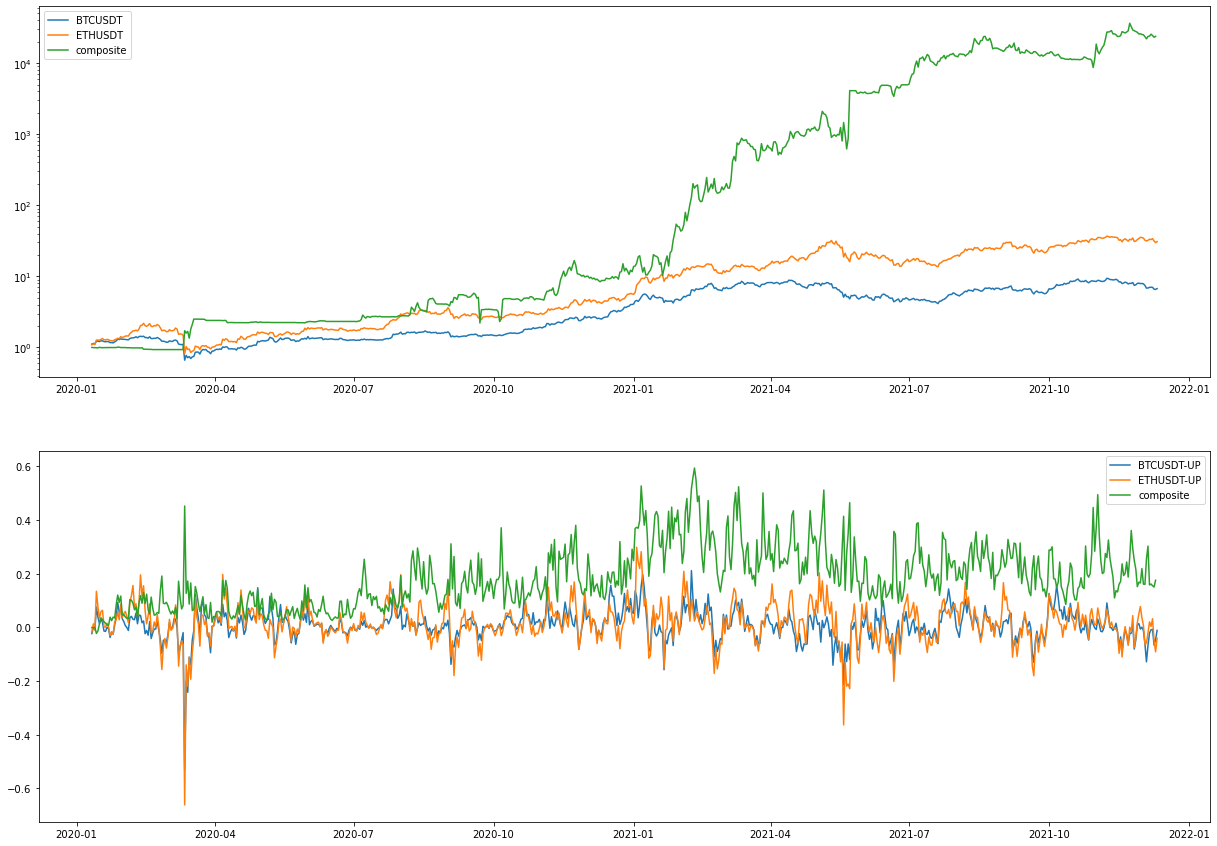

In [56]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
plt.yscale('log')
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].value_up, label="BTCUSDT-UP")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].value_up, label="ETHUSDT-UP")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()